In [2]:
# uncomment if needed
# !pip install scikit-learn
# !pip install transformers
# !pip install matplotlib
# !pip install seaborn
# !pip install PySastrawi
# !pip install keras
# !pip install imblearn
# !pip install fasttext
# !pip install wordcloud

In [3]:
import pandas as pd
import re

In [4]:
# --- Settings -------------------------------------------------------------
RAW_URL = "https://raw.githubusercontent.com/furaihan/proyek-data-mining/refs/heads/main/main.json"
TARGET_NAME = "data.json"        # final filename on disk
SAVE_TO_DRIVE = False            # set True to keep it in your Google Drive
DRIVE_FOLDER = "/content/drive/MyDrive/datasets"  # only used if SAVE_TO_DRIVE=True
# -------------------------------------------------------------------------

# 1️⃣  (Optional) Mount Google Drive
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    !mkdir -p "{DRIVE_FOLDER}"

# 2️⃣  Fetch the file and write it out
import requests, pathlib, time

def download_raw(url, outfile):
    t0 = time.time()
    r = requests.get(url, timeout=60)
    r.raise_for_status()               # 🔴 throws an error if 4xx/5xx
    pathlib.Path(outfile).write_bytes(r.content)
    print(f"✅ Saved {outfile}  ({len(r.content):,} bytes, {(time.time()-t0):.2f}s)")

out_path = f"{DRIVE_FOLDER}/{TARGET_NAME}" if SAVE_TO_DRIVE else TARGET_NAME
download_raw(RAW_URL, out_path)

# 3️⃣  Peek to confirm
!head -n 5 "{out_path}"


✅ Saved data.json  (2,681,346 bytes, 1.73s)


'head' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
df = pd.read_json('data.json')
df.head()

,title,label,label_score
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",non-clickbait,0
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,non-clickbait,0
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,clickbait,1
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",non-clickbait,0
4,"Terkait Mayat Bayi Mengenaskan di Tangerang, S...",non-clickbait,0


<Axes: ylabel='count'>

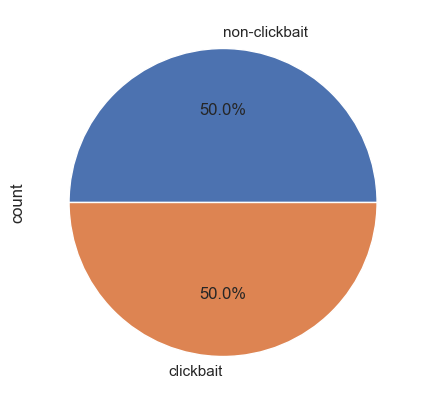

In [6]:
from matplotlib import pyplot as plt
import seaborn as sns

# pie plot with sns
plt.figure(figsize=(5, 5))
sns.set_theme()
df['label'].value_counts().plot.pie(autopct='%1.1f%%')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        17420 non-null  object
 1   label        17420 non-null  object
 2   label_score  17420 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 408.4+ KB


In [8]:
df.isnull().sum()

title          0
label          0
label_score    0
dtype: int64

# Preprocessing

In [9]:
from nltk.tokenize import word_tokenize
# tf idf
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
factory = StemmerFactory()
stopword_factory = StopWordRemoverFactory()
stopword_indonesia = stopword_factory.get_stop_words()
stemmer = factory.create_stemmer()

In [10]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\gerai\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [11]:
def preprocess_text(text):
    # remove non-alphabet characters
    text = re.sub(r'[^A-Za-z0-9!?]', ' ', text)
    text = re.sub(r'([!?])', r' \1 ', text)
    # remove whitespace
    text = text.strip()
    # remove newline
    text = text.replace('\n', ' ')
    # remove extra space
    text = re.sub(' +', ' ', text)
    # lowercase
    text = text.lower()
    # tokenize
    text = word_tokenize(text)
    # replace punctuation tokens
    text = ['EXCLAMATIONTOKEN' if token == '!' else 'QUESTIONTOKEN' if token == '?' else token for token in text]
    result = text
    return result

In [12]:
df['preprocessed_text'] = df['title'].apply(preprocess_text)
df['stemmed_text'] = df['preprocessed_text'].apply(lambda x: [stemmer.stem(word) for word in x]);

In [13]:
# convert back to exclamation and question tokens
df['stemmed_text'] = df['stemmed_text'].apply(lambda x: ['!' if word == 'exclamationtoken' else '?' if word == 'questiontoken' else word for word in x])

In [14]:
# calculate how many empty word in all stemmed accross all data
empty_word = 0
for i in range(len(df)):
    empty_word += df['stemmed_text'].iloc[i].count('')
print(empty_word)


0


In [15]:
# remove empty word
df['stemmed_text'] = df['stemmed_text'].apply(lambda x: [word for word in x if word != ''])

# Analisis Data

In [16]:
df['stopword_removed'] = df['stemmed_text'].apply(lambda x: [word for word in x if word not in stopword_indonesia])
# remove number in stopword removed
df['stopword_removed'] = df['stopword_removed'].apply(lambda x: [word for word in x if not word.isnumeric()])

In [17]:
df_clickbait = df[df['label'] == 'clickbait']
df_non_clickbait = df[df['label'] == 'non-clickbait']

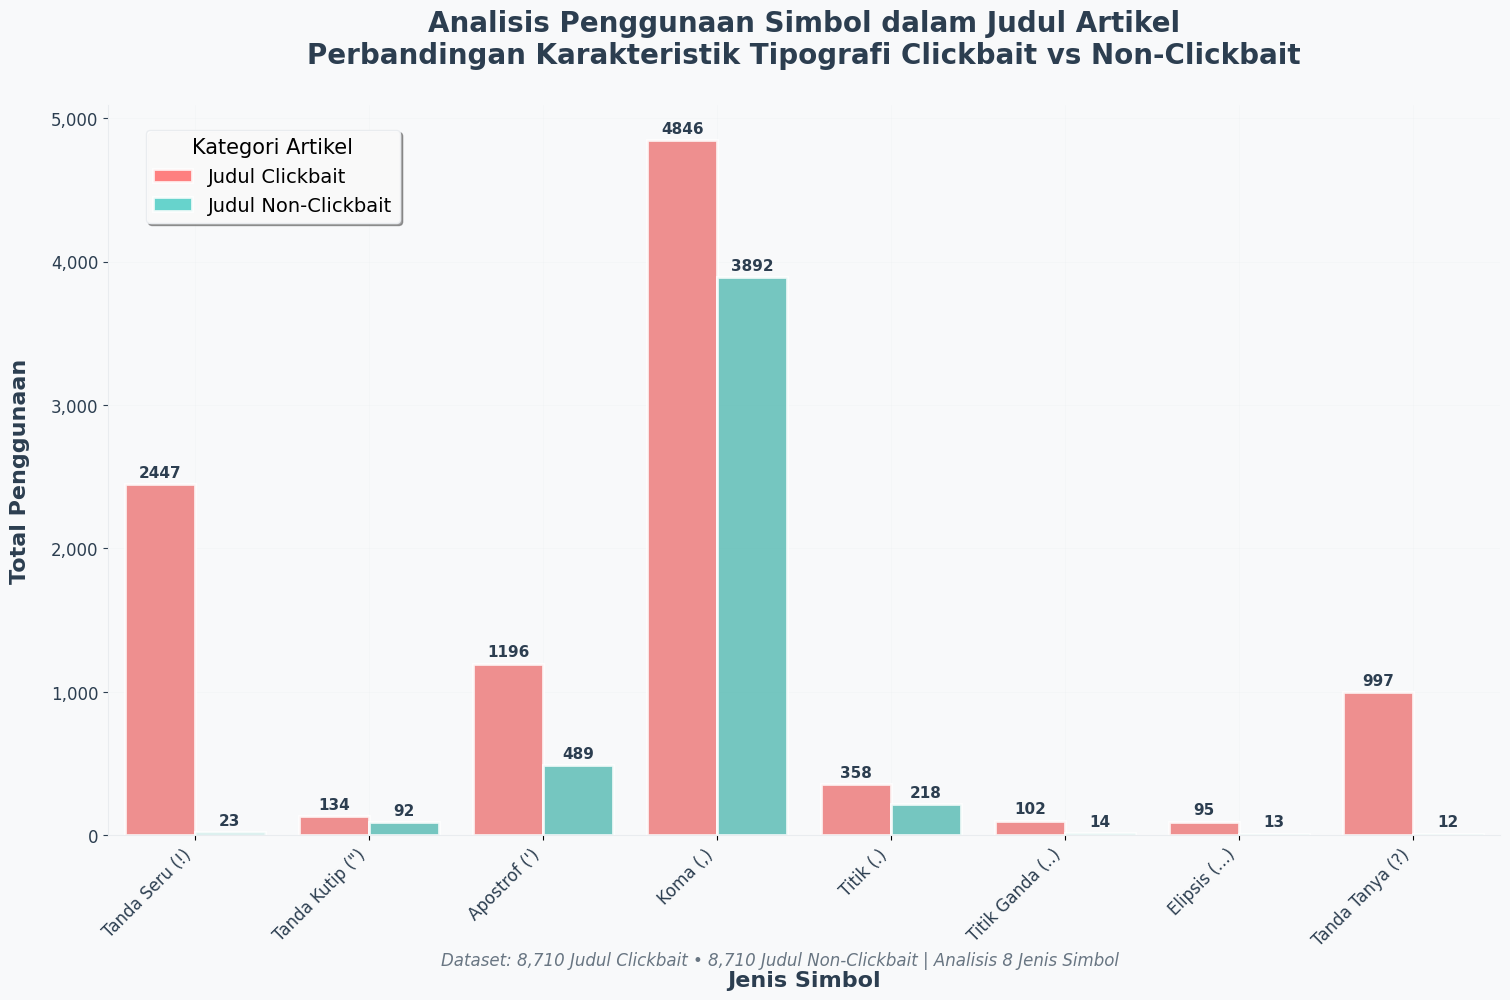

In [18]:
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.ticker import FixedLocator, FuncFormatter
from matplotlib import rcParams

# ✅ Set font that supports emoji
rcParams['font.family'] = 'Segoe UI Emoji'

# Define symbols to analyze
symbols = ['!', '?', '.', ',', '...', '"', '..', "'"]

# Function to count symbols in a string
def count_symbols(text, symbols):
    if pd.isna(text):
        return {sym: 0 for sym in symbols}
    return {sym: str(text).count(sym) for sym in symbols}

# Count for clickbait
clickbait_counts = df_clickbait['title'].apply(lambda x: pd.Series(count_symbols(x, symbols)))
clickbait_counts['label'] = 'Clickbait'

# Count for non-clickbait
non_clickbait_counts = df_non_clickbait['title'].apply(lambda x: pd.Series(count_symbols(x, symbols)))
non_clickbait_counts['label'] = 'Non-Clickbait'

# Combine both
symbol_df = pd.concat([clickbait_counts, non_clickbait_counts])

# Melt for seaborn barplot
melted = symbol_df.melt(id_vars='label', var_name='symbol', value_name='count')

# Group and sum for plotting
grouped = melted.groupby(['label', 'symbol'])['count'].sum().reset_index()

# Modern color palette
colors = {
    'clickbait': '#FF6B6B',
    'non_clickbait': '#4ECDC4',
    'background': '#F8F9FA',
    'text': '#2C3E50',
    'grid': '#E9ECEF',
    'accent': '#FFD93D'
}

# Set style
plt.style.use('default')
sns.set_palette([colors['clickbait'], colors['non_clickbait']])

# Create the plot
fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor(colors['background'])
ax.set_facecolor(colors['background'])

# Create barplot
barplot = sns.barplot(
    data=grouped,
    x='symbol',
    y='count',
    hue='label',
    ax=ax,
    palette=[colors['clickbait'], colors['non_clickbait']],
    alpha=0.85,
    edgecolor='white',
    linewidth=2
)

# Add value labels on top of bars
def add_value_labels():
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=11, fontweight='600',
                     color=colors['text'], padding=3)

add_value_labels()

# Customize titles and labels
ax.set_title('Analisis Penggunaan Simbol dalam Judul Artikel\n'
             'Perbandingan Karakteristik Tipografi Clickbait vs Non-Clickbait',
             fontsize=20, fontweight='700', color=colors['text'], pad=30)

ax.set_xlabel('Jenis Simbol', fontsize=16, fontweight='600', color=colors['text'], labelpad=15)
ax.set_ylabel('Total Penggunaan', fontsize=16, fontweight='600', color=colors['text'], labelpad=15)

# Define readable x-axis labels
symbol_labels = {
    '!': 'Tanda Seru (!)',
    '?': 'Tanda Tanya (?)',
    '.': 'Titik (.)',
    ',': 'Koma (,)',
    '...': 'Elipsis (...)',
    '"': 'Tanda Kutip (")',
    '..': 'Titik Ganda (..)',
    "'": "Apostrof (')"
}

# ✅ Apply FixedLocator before setting labels
symbols_in_order = grouped['symbol'].unique().tolist()
ax.set_xticks(range(len(symbols_in_order)))
new_labels = [symbol_labels.get(sym, sym) for sym in symbols_in_order]
ax.set_xticklabels(new_labels, rotation=45, ha='right', fontsize=12, color=colors['text'])

# Customize y-axis
ax.tick_params(axis='y', labelsize=12, colors=colors['text'])
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Grid and spines
ax.grid(True, alpha=0.3, color=colors['grid'], linestyle='-', linewidth=0.5, zorder=1)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(colors['grid'])
ax.spines['bottom'].set_color(colors['grid'])

# Legend customization
legend_elements = [
    mpatches.Rectangle((0, 0), 1, 1, facecolor=colors['clickbait'], alpha=0.85,
                       edgecolor='white', linewidth=2, label='Judul Clickbait'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor=colors['non_clickbait'], alpha=0.85,
                       edgecolor='white', linewidth=2, label='Judul Non-Clickbait')
]

legend = ax.legend(handles=legend_elements, loc='upper left',
                   frameon=True, fancybox=True, shadow=True,
                   fontsize=14, title='Kategori Artikel', title_fontsize=15,
                   bbox_to_anchor=(0.02, 0.98))
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.95)
legend.get_frame().set_edgecolor(colors['grid'])

# Footer
total_clickbait = len(df_clickbait)
total_non_clickbait = len(df_non_clickbait)
fig.text(0.5, 0.02,
         f'Dataset: {total_clickbait:,} Judul Clickbait • {total_non_clickbait:,} Judul Non-Clickbait | Analisis {len(symbols)} Jenis Simbol',
         ha='center', fontsize=12, style='italic', color=colors['text'], alpha=0.7)

# Layout tweaks
plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.15, left=0.08, right=0.95)
plt.show()


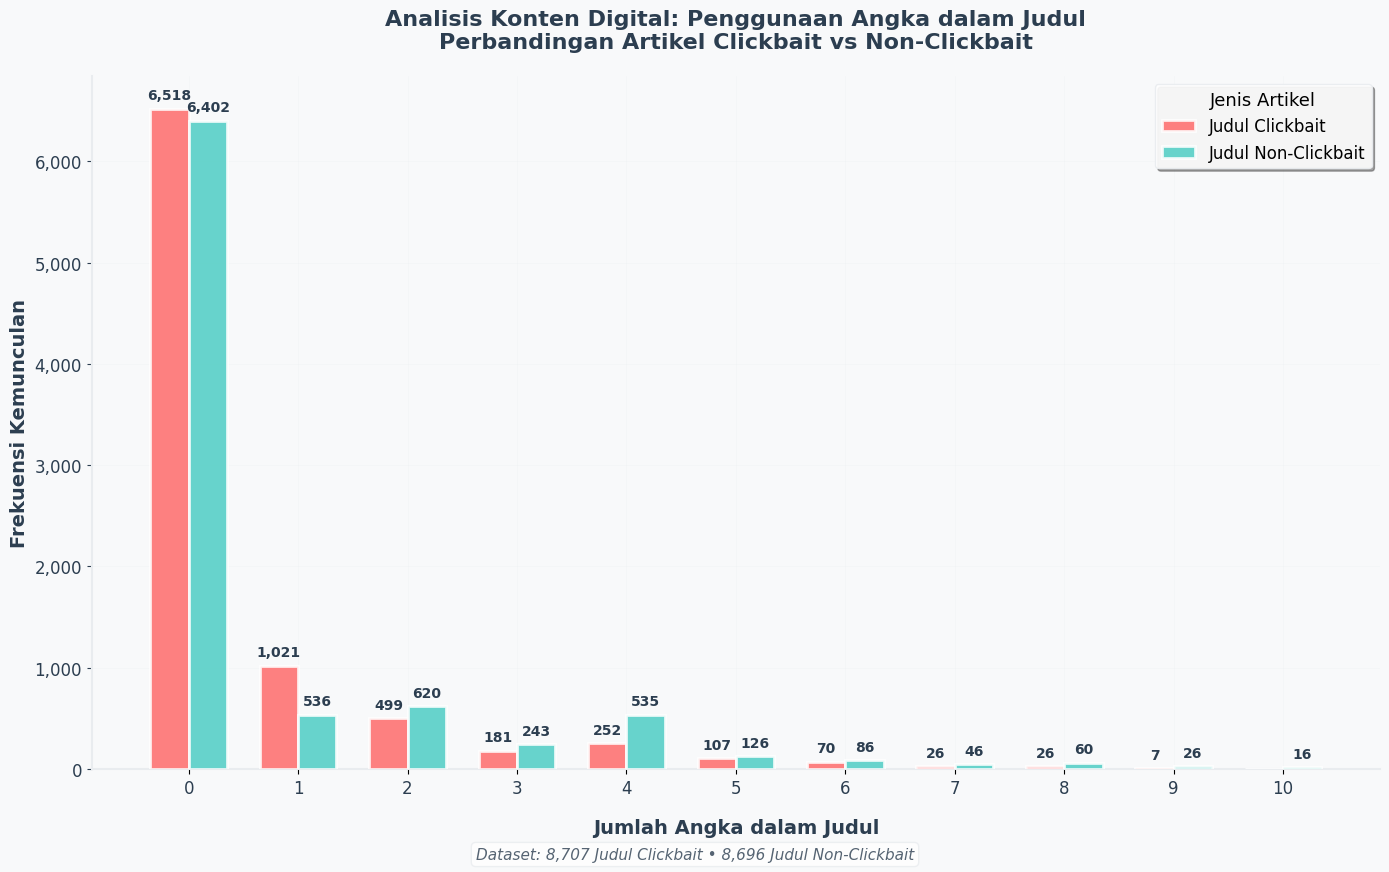

In [19]:
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

def count_digits(title):
    return len(re.findall(r'\d', str(title)))

# Apply digit counting directly without adding columns
clickbait_digit_counts = df_clickbait['title'].apply(count_digits)
non_clickbait_digit_counts = df_non_clickbait['title'].apply(count_digits)

# Create data for visualization (0-10 digits, including 0 for completeness)
digit_counts = []
for i in range(0, 11):
    clickbait_count = (clickbait_digit_counts == i).sum()
    non_clickbait_count = (non_clickbait_digit_counts == i).sum()
    digit_counts.append({
        'digits': i,
        'clickbait': clickbait_count,
        'non_clickbait': non_clickbait_count
    })

# Extract data for plotting
digits = [d['digits'] for d in digit_counts]
clickbait_counts = [d['clickbait'] for d in digit_counts]
non_clickbait_counts = [d['non_clickbait'] for d in digit_counts]

# Set up the plot with modern aesthetics
plt.style.use('default')
fig, ax = plt.subplots(figsize=(14, 9))  # Increased height slightly

# Modern color palette
colors = {
    'clickbait': '#FF6B6B',      # Vibrant coral red
    'non_clickbait': '#4ECDC4',   # Teal blue
    'background': '#F8F9FA',      # Light gray
    'text': '#2C3E50',           # Dark blue-gray
    'grid': '#E9ECEF'            # Light grid
}

# Set background color
fig.patch.set_facecolor(colors['background'])
ax.set_facecolor(colors['background'])

# Create grouped bar chart
x = np.arange(len(digits))
width = 0.35

# Create bars with gradient effect and rounded corners
bars1 = ax.bar(x - width/2, clickbait_counts, width, 
               label='Judul Clickbait', 
               color=colors['clickbait'],
               alpha=0.85,
               edgecolor='white',
               linewidth=2,
               zorder=3)

bars2 = ax.bar(x + width/2, non_clickbait_counts, width,
               label='Judul Non-Clickbait', 
               color=colors['non_clickbait'],
               alpha=0.85,
               edgecolor='white',
               linewidth=2,
               zorder=3)

# Add value labels on top of bars
def add_value_labels(bars, counts):
    for bar, count in zip(bars, counts):
        if count > 0:  # Only show label if count > 0
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + max(max(clickbait_counts), max(non_clickbait_counts)) * 0.01,
                    f'{count:,}', ha='center', va='bottom', 
                    fontweight='600', fontsize=10, color=colors['text'])

add_value_labels(bars1, clickbait_counts)
add_value_labels(bars2, non_clickbait_counts)

# Customize the plot
ax.set_xlabel('Jumlah Angka dalam Judul', fontsize=14, fontweight='600', color=colors['text'], labelpad=15)
ax.set_ylabel('Frekuensi Kemunculan', fontsize=14, fontweight='600', color=colors['text'])
ax.set_title('Analisis Konten Digital: Penggunaan Angka dalam Judul\n'
             'Perbandingan Artikel Clickbait vs Non-Clickbait', 
             fontsize=16, fontweight='700', color=colors['text'], pad=20)

# Set x-axis
ax.set_xticks(x)
ax.set_xticklabels(digits, fontsize=12, color=colors['text'])

# Customize y-axis
ax.tick_params(axis='y', labelsize=12, colors=colors['text'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Add subtle grid
ax.grid(True, alpha=0.3, color=colors['grid'], linestyle='-', linewidth=0.5, zorder=1)
ax.set_axisbelow(True)

# Create custom legend with better styling
legend_elements = [
    mpatches.Rectangle((0, 0), 1, 1, facecolor=colors['clickbait'], alpha=0.85, 
                      edgecolor='white', linewidth=2, label='Judul Clickbait'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor=colors['non_clickbait'], alpha=0.85, 
                      edgecolor='white', linewidth=2, label='Judul Non-Clickbait')
]

legend = ax.legend(handles=legend_elements, loc='upper right', 
                   frameon=True, fancybox=True, shadow=True,
                   fontsize=12, title='Jenis Artikel', title_fontsize=13)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)
legend.get_frame().set_edgecolor(colors['grid'])

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(colors['grid'])
ax.spines['bottom'].set_color(colors['grid'])

# Add subtle shadow effect
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Adjust layout first
plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.15)  # Added more bottom margin

# Add footer with dataset information in a better position
total_clickbait = sum(clickbait_counts)
total_non_clickbait = sum(non_clickbait_counts)
fig.text(0.5, 0.05, f'Dataset: {total_clickbait:,} Judul Clickbait • {total_non_clickbait:,} Judul Non-Clickbait', 
         ha='center', fontsize=11, style='italic', color=colors['text'], alpha=0.8,
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor=colors['grid']))

plt.show()

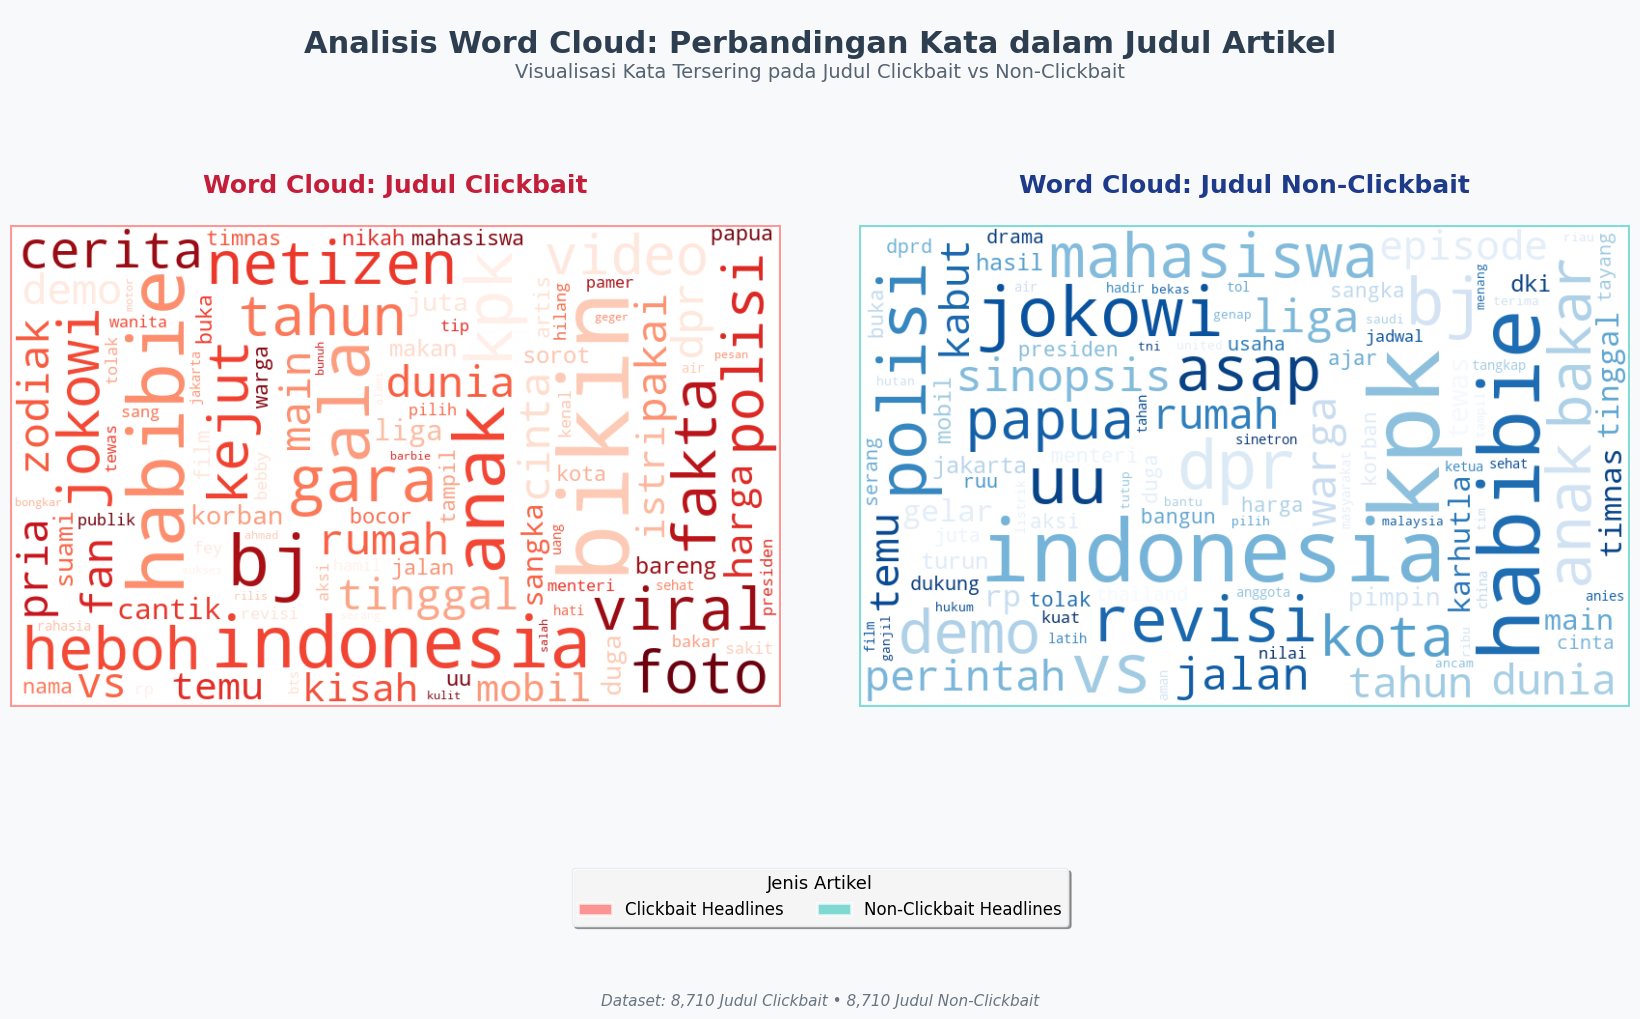

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Prepare the text data
clickbait_text = ' '.join(df_clickbait['stopword_removed'].explode())
non_clickbait_text = ' '.join(df_non_clickbait['stopword_removed'].explode())

# Modern color palette
colors = {
    'clickbait': '#FF6B6B',      # Vibrant coral red
    'non_clickbait': '#4ECDC4',   # Teal blue
    'background': '#F8F9FA',      # Light gray
    'text': '#2C3E50',           # Dark blue-gray
    'accent': '#E9ECEF'          # Light accent
}

# Create figure with modern styling
plt.style.use('default')
fig = plt.figure(figsize=(18, 12))  # Increased height to accommodate both legend and dataset info
fig.patch.set_facecolor(colors['background'])

# Create custom word clouds with enhanced styling
clickbait_wordcloud = WordCloud(
    width=800, 
    height=500,
    background_color='white',
    colormap='Reds',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=12,
    max_font_size=100,
    prefer_horizontal=0.7,
    collocations=False,
    margin=10
).generate(clickbait_text)

non_clickbait_wordcloud = WordCloud(
    width=800, 
    height=500,
    background_color='white',
    colormap='Blues',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=12,
    max_font_size=100,
    prefer_horizontal=0.7,
    collocations=False,
    margin=10
).generate(non_clickbait_text)

# Create subplots with enhanced spacing - adjusted for more bottom space
gs = fig.add_gridspec(2, 2, height_ratios=[0.1, 1], hspace=0.1, wspace=0.1)

# Add main title
title_ax = fig.add_subplot(gs[0, :])
title_ax.text(0.5, 0.5, 'Analisis Word Cloud: Perbandingan Kata dalam Judul Artikel', 
              ha='center', va='center', fontsize=22, fontweight='700', 
              color=colors['text'], transform=title_ax.transAxes)
title_ax.text(0.5, 0.1, 'Visualisasi Kata Tersering pada Judul Clickbait vs Non-Clickbait', 
              ha='center', va='center', fontsize=14, fontweight='400', 
              color=colors['text'], alpha=0.8, transform=title_ax.transAxes)
title_ax.axis('off')

# Clickbait subplot with decorative frame
ax1 = fig.add_subplot(gs[1, 0])
ax1.imshow(clickbait_wordcloud, interpolation='bilinear')
ax1.axis('off')

# Add stylized title for clickbait
ax1.text(0.5, 1.08, 'Word Cloud: Judul Clickbait', 
         ha='center', va='center', fontsize=18, fontweight='700', 
         color='#C41E3A', transform=ax1.transAxes)

# Add decorative border
rect1 = mpatches.Rectangle((0, 0), 1, 1, linewidth=3, edgecolor='#FF6B6B', 
                          facecolor='none', alpha=0.7, transform=ax1.transAxes)
ax1.add_patch(rect1)

# Non-clickbait subplot with decorative frame
ax2 = fig.add_subplot(gs[1, 1])
ax2.imshow(non_clickbait_wordcloud, interpolation='bilinear')
ax2.axis('off')

# Add stylized title for non-clickbait
ax2.text(0.5, 1.08, 'Word Cloud: Judul Non-Clickbait', 
         ha='center', va='center', fontsize=18, fontweight='700', 
         color='#1E3A8A', transform=ax2.transAxes)

# Add decorative border
rect2 = mpatches.Rectangle((0, 0), 1, 1, linewidth=3, edgecolor='#4ECDC4', 
                          facecolor='none', alpha=0.7, transform=ax2.transAxes)
ax2.add_patch(rect2)

# Add color indicators/legend - positioned higher
legend_elements = [
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#FF6B6B', alpha=0.7, 
                      edgecolor='white', linewidth=2, label='Clickbait Headlines'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#4ECDC4', alpha=0.7, 
                      edgecolor='white', linewidth=2, label='Non-Clickbait Headlines')
]

# Position legend higher to avoid overlap with dataset info
legend = fig.legend(handles=legend_elements, loc='lower center', 
                   bbox_to_anchor=(0.5, 0.08), ncol=2,  # Moved up from 0.02 to 0.08
                   frameon=True, fancybox=True, shadow=True,
                   fontsize=12, title='Jenis Artikel', title_fontsize=13)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)
legend.get_frame().set_edgecolor(colors['accent'])

# Add dataset information - positioned lower and separated from legend
total_clickbait = len(df_clickbait)
total_non_clickbait = len(df_non_clickbait)
fig.text(0.5, 0.02, f'Dataset: {total_clickbait:,} Judul Clickbait • {total_non_clickbait:,} Judul Non-Clickbait', 
         ha='center', fontsize=11, style='italic', color=colors['text'], alpha=0.7)

# Final layout adjustment - increased bottom margin for proper spacing
plt.subplots_adjust(top=0.85, bottom=0.18, left=0.05, right=0.95)  # Increased bottom from 0.15 to 0.18
plt.show()

🔄 Mengekstrak bigram dari dataset...
✅ Found 10 clickbait bigrams
✅ Found 10 non-clickbait bigrams


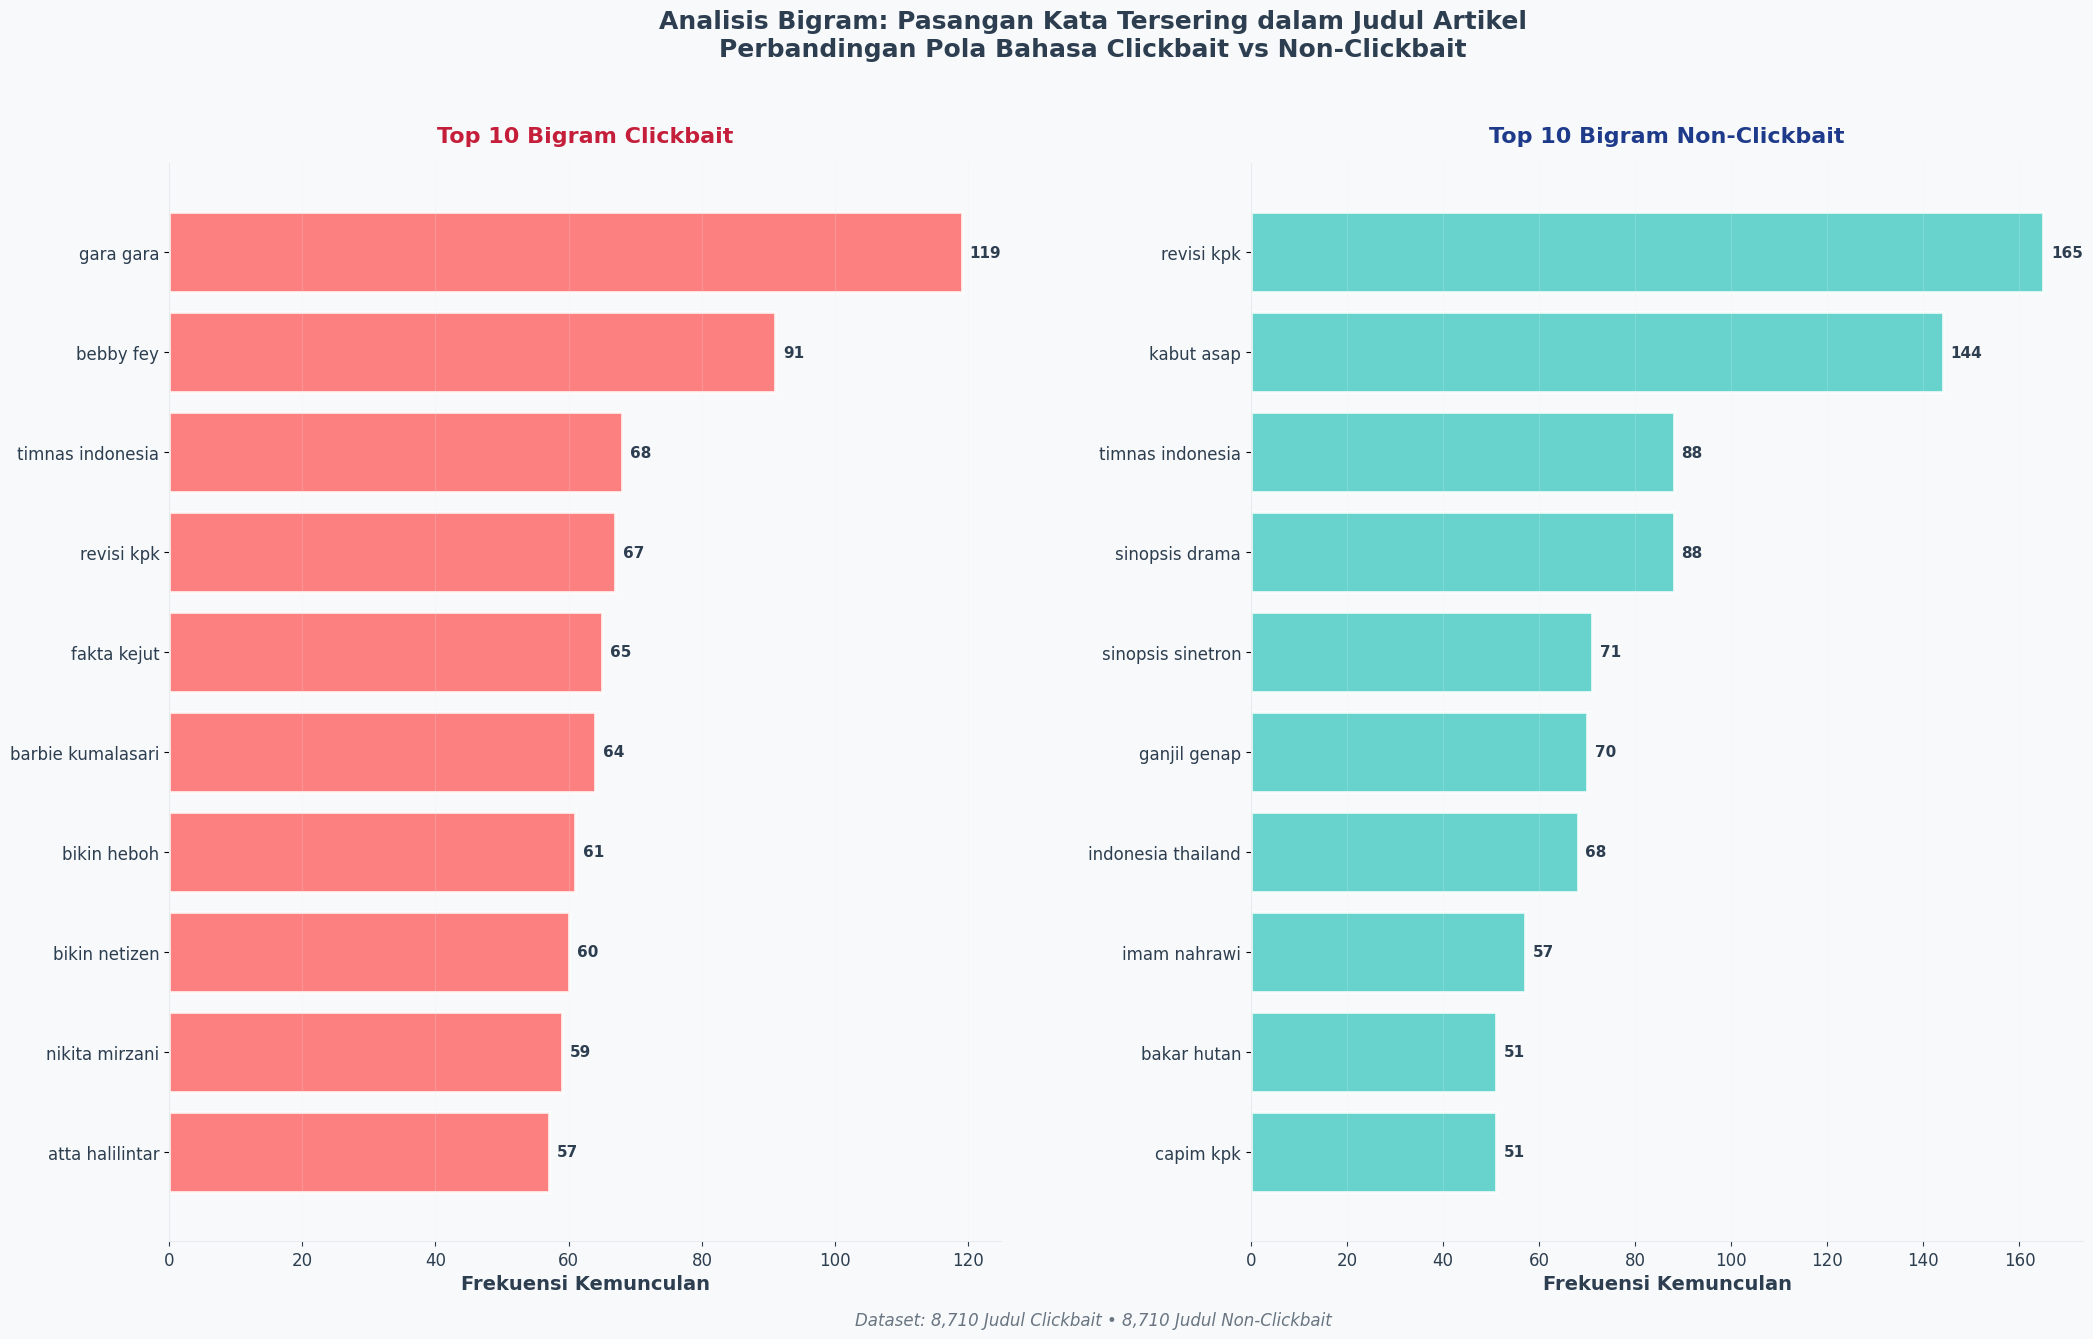

In [21]:
from collections import Counter
from nltk import bigrams

def extract_bigrams(text_series, top_n=10):
    """Extract top n bigrams from a text series"""
    # Combine all text
    all_text = []
    for text_list in text_series:
        if isinstance(text_list, list):
            all_text.extend(text_list)
        elif isinstance(text_list, str):
            # If it's a string, split it
            all_text.extend(text_list.split())
        elif pd.notna(text_list):
            all_text.extend(str(text_list).split())
    
    # Filter out very short words and numbers
    filtered_words = [word for word in all_text if len(word) > 2 and not word.isdigit()]
    
    # Generate bigrams
    bigram_list = list(bigrams(filtered_words))
    
    # Count bigrams
    bigram_counts = Counter(bigram_list)
    
    # Get top n bigrams
    top_bigrams = bigram_counts.most_common(top_n)
    
    return top_bigrams

# Extract bigrams for both datasets
print("🔄 Mengekstrak bigram dari dataset...")
clickbait_bigrams = extract_bigrams(df_clickbait['stopword_removed'], top_n=10)
non_clickbait_bigrams = extract_bigrams(df_non_clickbait['stopword_removed'], top_n=10)

print(f"✅ Found {len(clickbait_bigrams)} clickbait bigrams")
print(f"✅ Found {len(non_clickbait_bigrams)} non-clickbait bigrams")

# Prepare data for visualization
def prepare_bigram_data(bigrams, label):
    data = []
    for i, (bigram, count) in enumerate(bigrams):
        data.append({
            'bigram': f"{bigram[0]} {bigram[1]}",
            'count': count,
            'label': label,
            'rank': i + 1
        })
    return data

clickbait_data = prepare_bigram_data(clickbait_bigrams, 'Clickbait')
non_clickbait_data = prepare_bigram_data(non_clickbait_bigrams, 'Non-Clickbait')

# Combine data
bigram_df = pd.DataFrame(clickbait_data + non_clickbait_data)

# Modern color palette
colors = {
    'clickbait': '#FF6B6B',      # Vibrant coral red
    'non_clickbait': '#4ECDC4',   # Teal blue
    'background': '#F8F9FA',      # Light gray
    'text': '#2C3E50',           # Dark blue-gray
    'grid': '#E9ECEF',           # Light grid
    'accent': '#FFD93D'          # Gold accent
}

# Create the visualization with better spacing
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 14))  # Increased figure size
fig.patch.set_facecolor(colors['background'])

# Clickbait bigrams plot
if clickbait_data:
    cb_df = pd.DataFrame(clickbait_data)
    cb_df = cb_df.sort_values('count', ascending=True)  # Sort for horizontal bar
    
    bars1 = ax1.barh(range(len(cb_df)), cb_df['count'], 
                     color=colors['clickbait'], alpha=0.85,
                     edgecolor='white', linewidth=2)
    
    ax1.set_yticks(range(len(cb_df)))
    ax1.set_yticklabels(cb_df['bigram'], fontsize=12, color=colors['text'])
    ax1.set_xlabel('Frekuensi Kemunculan', fontsize=14, fontweight='600', color=colors['text'])
    ax1.set_title('Top 10 Bigram Clickbait', fontsize=16, fontweight='700', 
                  color='#C41E3A', pad=15)  # Reduced font size and padding
    
    # Add value labels
    for i, (bar, count) in enumerate(zip(bars1, cb_df['count'])):
        width = bar.get_width()
        ax1.text(width + max(cb_df['count']) * 0.01, bar.get_y() + bar.get_height()/2, 
                f'{count:,}', ha='left', va='center', fontweight='600', 
                fontsize=11, color=colors['text'])

ax1.set_facecolor(colors['background'])
ax1.grid(True, alpha=0.3, color=colors['grid'], linestyle='-', linewidth=0.5, axis='x')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color(colors['grid'])
ax1.spines['left'].set_color(colors['grid'])

# Non-clickbait bigrams plot
if non_clickbait_data:
    ncb_df = pd.DataFrame(non_clickbait_data)
    ncb_df = ncb_df.sort_values('count', ascending=True)  # Sort for horizontal bar
    
    bars2 = ax2.barh(range(len(ncb_df)), ncb_df['count'], 
                     color=colors['non_clickbait'], alpha=0.85,
                     edgecolor='white', linewidth=2)
    
    ax2.set_yticks(range(len(ncb_df)))
    ax2.set_yticklabels(ncb_df['bigram'], fontsize=12, color=colors['text'])
    ax2.set_xlabel('Frekuensi Kemunculan', fontsize=14, fontweight='600', color=colors['text'])
    ax2.set_title('Top 10 Bigram Non-Clickbait', fontsize=16, fontweight='700', 
                  color='#1E3A8A', pad=15)  # Reduced font size and padding
    
    # Add value labels
    for i, (bar, count) in enumerate(zip(bars2, ncb_df['count'])):
        width = bar.get_width()
        ax2.text(width + max(ncb_df['count']) * 0.01, bar.get_y() + bar.get_height()/2, 
                f'{count:,}', ha='left', va='center', fontweight='600', 
                fontsize=11, color=colors['text'])

ax2.set_facecolor(colors['background'])
ax2.grid(True, alpha=0.3, color=colors['grid'], linestyle='-', linewidth=0.5, axis='x')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_color(colors['grid'])
ax2.spines['left'].set_color(colors['grid'])

# Format x-axis for both plots
for ax in [ax1, ax2]:
    ax.tick_params(axis='x', labelsize=12, colors=colors['text'])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Add main title with better positioning
fig.suptitle('Analisis Bigram: Pasangan Kata Tersering dalam Judul Artikel\n'
             'Perbandingan Pola Bahasa Clickbait vs Non-Clickbait', 
             fontsize=18, fontweight='700', color=colors['text'], y=0.96)  # Adjusted position

# Add dataset information
total_clickbait = len(df_clickbait)
total_non_clickbait = len(df_non_clickbait)
fig.text(0.5, 0.02, f'Dataset: {total_clickbait:,} Judul Clickbait • {total_non_clickbait:,} Judul Non-Clickbait', 
         ha='center', fontsize=12, style='italic', color=colors['text'], alpha=0.7)

# Improved layout with more space for titles
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.08, left=0.08, right=0.95, wspace=0.3)  # Better spacing
plt.show()

# Feature Engineering

In [22]:
angka = ['nol', 'satu', 'dua', 'tiga', 'empat', 'lima', 'enam', 'tujuh', 'delapan', 'sembilan']
potential_clickbait_words = ['bikin', 'viral', 'gara', 'fakta', 'kejut', 'kamu', 'wajib', 'pakai', 'ala', 'heboh', 'duga', 'geger', 'video', 'foto', 'cantik']

def count_full_word_capitals(text):
    return sum(len(word) for word in text.split() if word.isupper() and len(word) > 1)

def count_all_caps_words(text):
    return sum(1 for word in text.split() if word.isupper() and len(word) > 1)

def check_features(text):
    words = text.split()
    word_count = len(words)
    avg_word_length = sum(len(w) for w in words) / word_count if word_count > 0 else 0

    stemmed_words = [stemmer.stem(word.lower()) for word in words]

    result = []

    # Feature 1: contains exclamation mark
    result.append(1 if '!' in text else 0)
    # Feature 2: contains question mark
    result.append(1 if '?' in text else 0)
    # Feature 3: contains multiple exclamation marks
    result.append(1 if '!!' in text else 0)
    result.append(1 if '..' in text else 0)
    # Feature 6: contains potential clickbait words (after stemming)
    result.append(1 if any(stem in potential_clickbait_words for stem in stemmed_words) else 0)
    # Feature 7: count of exclamation marks
    result.append(text.count('!'))
    # Feature 8: total capital letters from full caps words
    result.append(count_full_word_capitals(text))
    # Feature 9: total length of text (in characters)
    result.append(len(text))
    # Feature 10: word count
    result.append(word_count)
    # Feature 11: average word length
    result.append(avg_word_length)
    # Feature 12: starts with number (digit or number word)
    result.append(1 if words and (words[0].isdigit() or words[0].lower() in angka) else 0)
    # Feature 13: count of full-uppercase words
    result.append(count_all_caps_words(text))

    return result

# Apply to DataFrame
df['features'] = df['title'].apply(check_features)

# Reorder columns if needed
df = df[['title', 'label', 'label_score', 'features', 'preprocessed_text', 'stemmed_text']]


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              17420 non-null  object
 1   label              17420 non-null  object
 2   label_score        17420 non-null  int64 
 3   features           17420 non-null  object
 4   preprocessed_text  17420 non-null  object
 5   stemmed_text       17420 non-null  object
dtypes: int64(1), object(5)
memory usage: 816.7+ KB


# Pipeline Building

In [1]:
from sklearn.base import BaseEstimator, TransformerMixin

class StructuredFeaturesTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        # Convert features column to numpy array
        return np.array(X.tolist(), dtype=np.float32)

# Custom transformer for text data
class TextTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        # Join stemmed text back into strings
        return X.apply(lambda x: ' '.join(x))

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

preprocessor = ColumnTransformer([
    ('tfidf', Pipeline([
        ('text_prep', TextTransformer()),
        ('vectorizer', TfidfVectorizer(max_features=5000, min_df=2))
    ]), 'stemmed_text'),
    ('structured', StructuredFeaturesTransformer(), 'features')
])

In [25]:
from lightgbm import LGBMClassifier

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.02,
        subsample=0.7,
        subsample_freq=1,
        max_depth=15,
        min_child_samples=5,
        colsample_bytree=0.5,
        reg_alpha=0.0,
        random_state=1453,
        n_jobs=-1,
        verbose=-1
    ))
])

In [26]:
X = df[['stemmed_text', 'features']]  # Only these two columns needed
y = df['label_score'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("Data prepared for pipeline!")

X shape: (17420, 2)
y shape: (17420,)
Data prepared for pipeline!


In [167]:
# {'model__validation_fraction': 0.1, 'model__tol': 0.0001, 'model__subsample': 0.7, 'model__n_iter_no_change': 10, 'model__n_estimators': np.int64(800), 'model__min_samples_leaf': 5, 'model__max_features': 0.5, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__ccp_alpha': 0.0}

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1453)
accuracy = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy", n_jobs=1)

print("Accuracy per fold:", np.round(accuracy, 4))
print("Mean accuracy:", accuracy.mean())

Accuracy per fold: [0.8255 0.8272 0.8278 0.8292 0.8218]
Mean accuracy: 0.8262916188289322


In [28]:
pipeline.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('tfidf',
                                                  Pipeline(steps=[('text_prep',
                                                                   TextTransformer()),
                                                                  ('vectorizer',
                                                                   TfidfVectorizer(max_features=5000,
                                                                                   min_df=2))]),
                                                  'stemmed_text'),
                                                 ('structured',
                                                  StructuredFeaturesTransformer(),
                                                  'features')])),
                ('model',
                 LGBMClassifier(colsample_bytree=0.5, learning_rate=0.02,
                                max_depth=15, min_child_samples=5,
                                n_estimators=1000, n_jobs=-1, random_state=1453,
                                subsample=0.7, subsample_freq=1, verbose=-1))])

In [29]:
import joblib

joblib.dump(pipeline, "tfidf_pipeline_model.pkl")
print("Pipeline saved as 'tfidf_pipeline_model.pkl'")

Pipeline saved as 'tfidf_pipeline_model.pkl'


In [30]:
loaded_pipeline = joblib.load("tfidf_pipeline_model.pkl")

# Test prediction on first few samples
sample_predictions = loaded_pipeline.predict(X.head())
print("Sample predictions:", sample_predictions)
print("Actual labels:", y[:len(sample_predictions)])

Sample predictions: [0 0 1 0 0]
Actual labels: [0 0 1 0 0]


In [31]:
fitted_preprocessor = pipeline.named_steps['preprocessing']

# Get TF-IDF feature names
tfidf_features = fitted_preprocessor.named_transformers_['tfidf'].named_steps['vectorizer'].get_feature_names_out()
structured_feature_names = [f'structured_feature_{i}' for i in range(13)]  # You have 13 structured features

# Combine feature names
all_feature_names = list(structured_feature_names) + list(tfidf_features)

print(f"Total features: {len(all_feature_names)}")
print(f"Structured features: {len(structured_feature_names)}")
print(f"TF-IDF features: {len(tfidf_features)}")

Total features: 5013
Structured features: 13
TF-IDF features: 5000


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid - note the 'model__' prefix for model parameters
param_dist = {
    "model__num_leaves": [31, 50, 70, 100],
    "model__max_depth": [3, 4, 5, 6, 7, 8],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__n_estimators": np.arange(300, 1001, 100),
    "model__subsample": [0.6, 0.7, 0.8],
    "model__colsample_bytree": [0.5, 0.7, 1.0],
    "model__reg_alpha": [0, 0.1, 0.5],
    "model__reg_lambda": [0, 0.1, 0.5],
    "preprocessing__tfidf__vectorizer__max_features": [3000, 5000, 7000],
    "preprocessing__tfidf__vectorizer__min_df": [2, 3, 5]
}

# Create RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=100,  # Reduced for faster execution
    scoring="accuracy",
    n_jobs=-1,
    cv=cv,
    verbose=2,
    random_state=1453
)



In [ ]:
# Uncomment to run (this will take time):
# random_search.fit(X, y)
# print("Best parameters found:", random_search.best_params_)
# print("Best CV accuracy:", random_search.best_score_)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters found: {'model__subsample': 0.6, 'model__reg_lambda': 0.1, 'model__reg_alpha': 0.5, 'model__num_leaves': 50, 'model__n_estimators': np.int64(800), 'model__max_depth': 6, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Best CV accuracy: 0.7916666666666667
